In [ ]:
!pip install igraph
import igraph as ig
import matplotlib.pyplot as plt
import numpy as np
import math
import random
import itertools
import operator
import networkx as nx
from scipy import stats


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 41.8 MB/s eta 0:00:00


"\nfig, ax = plt.subplots()\nig.plot(\n    g,\n    target=ax,\n    layout='circle',\n    vertex_color='steelblue',\n    vertex_label=range(g.vcount()),\n    edge_width=1,\n    edge_color='#666',\n    edge_align_label=True,\n    edge_background='white'\n)\n"

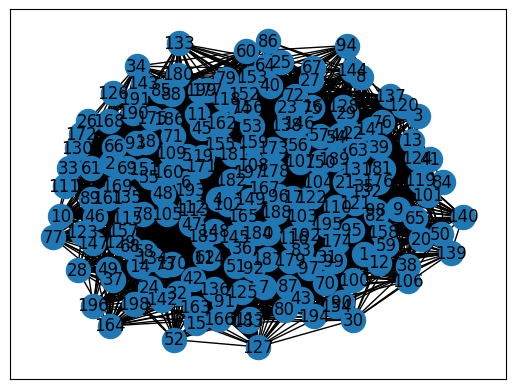

In [ ]:
from networkx.generators.random_graphs import erdos_renyi_graph
import networkx as nx

v = 200
p = 0.20
G = erdos_renyi_graph(v, p)
#G = nx.barabasi_albert_graph(100, 2)
E=[]
for i in G.edges:
  E.append(i)

allowedWeightValues = list(range(1,5))  #allowedWeightValues = [1, 2, 3, 4, 5]
noOfEdges = len(E)
g = ig.Graph(v, E)


nx.draw_networkx(G)
"""
fig, ax = plt.subplots()
ig.plot(
    g,
    target=ax,
    layout='circle',
    vertex_color='steelblue',
    vertex_label=range(g.vcount()),
    edge_width=1,
    edge_color='#666',
    edge_align_label=True,
    edge_background='white'
)
"""

In [ ]:
def findSEPR(path, WT):
  sEPR = max(WT)
  for i in range(len(path[0])-1):
    if (path[0][i],path[0][i+1]) in E:
      index = E.index((path[0][i],path[0][i+1]))
    else:
      index = E.index((path[0][i+1],path[0][i]))
    if sEPR >= WT[index]:
      sEPR = WT[index]
  return sEPR
def updatePathWeight(path, pathWeight, updateFactor):
  for i in range(len(path[0])-1):
    if (path[0][i],path[0][i+1]) in E:
      index = E.index((path[0][i],path[0][i+1]))
    else:
      index = E.index((path[0][i+1],path[0][i]))
    pathWeight[index] = pathWeight[index] - updateFactor
  return pathWeight

In [ ]:
AllPath = dict()
def getAllShortestPath(NodePairs):
  AllPath.clear()
  for (x,y) in NodePairs:
    if AllPath.get(x) == None:
      AllPath[x] = {}
    RX = [p for p in nx.all_simple_paths(G, x, y,2)]
    RX.sort(key=len)
    AllPath[x][y] = RX

In [ ]:
# Uses all_simple_paths
def splitScheduling(SN):
  RD,RDT,RsPathL,RsPaths,RDN, RST = [list(t) for t in zip(*SN)]
  T = max(RDT)
  SCHD = [[] for i in range(0,T)]
  WT = [[x for x in W] for i in range(0,T)]
  EPRServed = 0
  DServed = 0
  for i in range(len(RD)):
    RX = AllPath[RDN[i][0]][RDN[i][1]]
    #print(RX)
    for counter, path in enumerate(RX):
      pathL = len(path) - 1
      #print(path)
      if pathL < math.pow(2, RDT[i]-RST[i]) and RD[i]>0:
        t = RST[i]
        while t<(RDT[i]-math.ceil(math.log(pathL))) and RD[i]>0:
          sEPR = findSEPR([path], WT[t])
          if sEPR>0:
            if RD[i] > sEPR:
              SCHD[t].append((RDN[i],sEPR))
              EPRServed += sEPR
              RD[i] -= sEPR
              WT[t] = updatePathWeight([path], WT[t], sEPR)
              t = t + math.ceil(math.log2(pathL))
            else:
              EPRServed += RD[i]
              WT[t] = updatePathWeight([path], WT[t], RD[i])
              SCHD[t].append((RDN[i],RD[i]))
              RD[i] = 0
              DServed += 1
          else:
            t = t + 1;
  return EPRServed, SCHD, DServed

In [ ]:
W = random.choices(allowedWeightValues, k=noOfEdges)
iterations = 50
max_number_of_demands = 5001
lowerBound = 1000
step = 1000
burst = 10

demand_range = np.arange(lowerBound, max_number_of_demands, step)
num_points = len(demand_range)

# MODIFIED: 2D numpy arrays (iterations x num_points) to store trial raw data
all_eprres1 = np.zeros((iterations, num_points))
all_eprres2 = np.zeros((iterations, num_points))
all_dres1 = np.zeros((iterations, num_points))
all_dres2 = np.zeros((iterations, num_points))

for iteration in range(iterations):
  print(f'iteration: {iteration}')

  for d_idx, num_demands in enumerate(demand_range):
    # MODIFIED: Reset sPaths and sPathL inside loop per demand setting
    sPaths = list()
    sPathL = []

    k = num_demands
    CP = random.sample(list((x,y) for x,y in itertools.product(range(v), repeat = 2) if x!=y and x<y), k=k)
    DN=[]
    for i in CP:
      RX = [p for p in nx.all_simple_paths(G, i[0], i[1],2)]
      if len(RX) != 0:
        DN.append(i)
    noOfDemands = len(DN)
    print("No of Demands", noOfDemands)
    D = random.choices(list(range(1,20)), k=noOfDemands)
    DST0 = [0 for a in DN]
    DT0 = random.choices(list(range(5,10)), k=noOfDemands)
    DST = random.choices(list(range(0,5)), k=noOfDemands)
    DT = [a+burst for a in DST]
    getAllShortestPath(DN)

    for i in DN:
      shortestPath = g.get_shortest_paths(i[0], to=i[1], output="vpath")
      sPaths.append(shortestPath)
      sPathL.append(len(shortestPath[0])-1)

    S = sorted(zip(D, DT, sPathL, sPaths, DN, DST), key = lambda x: (x[2], x[1], x[0]))
    S_CL = sorted(zip(D, DT0, sPathL, sPaths, DN, DST0), key = lambda x: (x[2], x[1], x[0]))

    eprserved1, schd1, dserved1 = splitScheduling(S)
    eprserved2, schd2, dserved2 = splitScheduling(S_CL)

    # MODIFIED: Save trial metric ratios directly to matrix
    all_eprres1[iteration, d_idx] = eprserved1 / sum(D)
    all_eprres2[iteration, d_idx] = eprserved2 / sum(D)
    all_dres1[iteration, d_idx] = dserved1 / len(D)
    all_dres2[iteration, d_idx] = dserved2 / len(D)

iteration: 0
No of Demands 999
No of Demands 1998
No of Demands 3000
No of Demands 4000
No of Demands 5000
iteration: 1
No of Demands 998
No of Demands 1999
No of Demands 3000
No of Demands 4000
No of Demands 5000
iteration: 2
No of Demands 999
No of Demands 2000
No of Demands 3000
No of Demands 4000
No of Demands 5000
iteration: 3
No of Demands 1000
No of Demands 2000
No of Demands 3000
No of Demands 3999
No of Demands 4999
iteration: 4
No of Demands 1000
No of Demands 2000
No of Demands 2998
No of Demands 3998
No of Demands 4999
iteration: 5
No of Demands 1000
No of Demands 1999
No of Demands 3000
No of Demands 4000
No of Demands 4998
iteration: 6
No of Demands 1000
No of Demands 1999
No of Demands 3000
No of Demands 3999
No of Demands 4999
iteration: 7
No of Demands 999
No of Demands 2000
No of Demands 3000
No of Demands 4000
No of Demands 5000
iteration: 8
No of Demands 1000
No of Demands 1999
No of Demands 2998
No of Demands 3998
No of Demands 5000
iteration: 9
No of Demands 1000


In [ ]:
def compute_mean_and_ci(data_matrix, confidence=0.95):
    means = np.mean(data_matrix, axis=0)
    sem = stats.sem(data_matrix, axis=0)
    h = sem * stats.t.ppf((1 + confidence) / 2., iterations - 1)
    return means, h

In [ ]:
mean_eprres1, ci_eprres1 = compute_mean_and_ci(all_eprres1)
mean_eprres2, ci_eprres2 = compute_mean_and_ci(all_eprres2)
mean_dres1, ci_dres1 = compute_mean_and_ci(all_dres1)
mean_dres2, ci_dres2 = compute_mean_and_ci(all_dres2)

In [ ]:
plt.figure(figsize=(8, 6))

series_config = [
    (mean_eprres1, ci_eprres1, 'b', 'dashed', 'Fraction of EPRs served using scattered demands'),
    (mean_eprres2, ci_eprres2, 'y', 'dashdot', 'Fraction of EPRs served using clustered demands'),
    (mean_dres1, ci_dres1, 'r', 'solid', 'Fraction of Demands served using scattered demands'),
    (mean_dres2, ci_dres2, 'g', 'dotted', 'Fraction of Demands served using clustered demands'),
]

for mean_val, ci_val, color, style, label in series_config:
    plt.plot(demand_range, mean_val, color=color, label=label, linestyle=style)
    # ADDED: Render semi-transparent 95% CI bands
    plt.fill_between(demand_range, mean_val - ci_val, mean_val + ci_val, color=color, alpha=0.15)

plt.xlabel("No of demands")
plt.ylabel("Fraction")
plt.legend(bbox_to_anchor=(0.5, 1.28), loc='upper center')
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('vCluster_with_CI.png', bbox_inches='tight', dpi=500)
plt.show()